In [1]:
import numpy as np  
import matplotlib.pyplot as plt  
from sklearn.preprocessing import MinMaxScaler  
from sklearn.model_selection import train_test_split 
import torch  
import torch.nn as nn  
import torch.optim as optim 

In [2]:
import nn_fncs
import numpy as np
import scipy.io


mat_data= scipy.io.loadmat('kinematics_data2.mat', )
data_input = mat_data.get('nn_input')[:,:8]
data_output = mat_data.get('nn_output')
data_input = np.expand_dims(data_input, axis=2)
print(data_output[0]) 
# data_output = np.concatenate((data_output[:,1:9],data_output[:,10:]), axis=1)
data_output = np.concatenate((data_output[:,1:9],data_output[:,10:18]), axis=1)
print(data_output[0]) 
print("Input and output data shapes:")
print(data_input.shape)
print(data_output.shape)
# # Rearrange output data
# x_coords = data_output[:, :8]   # shape: (muestras, 8)
# y_coords = data_output[:, 8:]   # shape: (muestras, 8)
# data_reorganized = np.stack([x_coords, y_coords], axis=2)
# print(data_reorganized[0])
# print(data_reorganized.shape)
# data_output = data_reorganized

[ 0.054       0.09423059  0.14723393  0.17944634  0.17518745  0.17216619
  0.14497659  0.14685895  0.17325329  0.          0.03602083  0.04634777
  0.08968783  0.14351962  0.19743504  0.24409043  0.29805761  0.46397126
  0.46397126  6.12846318  0.7302452  -0.53782011  0.73920541  0.71811616
 -0.02297188  0.47167946 -0.56252362 -0.12289709]
[0.09423059 0.14723393 0.17944634 0.17518745 0.17216619 0.14497659
 0.14685895 0.17325329 0.03602083 0.04634777 0.08968783 0.14351962
 0.19743504 0.24409043 0.29805761 0.46397126]
Input and output data shapes:
(500000, 8, 1)
(500000, 16)


In [3]:
def point_distances_from_sample(sample):
    """
    Calculate Euclidean distances between paired (x, y) coordinates in a sample.
    Pairs: (0,8), (1,9), ..., (7,15)
    Args:
        sample (np.ndarray): 1D array with 16 elements, first 8 are x, next 8 are y.
    Returns:
        np.ndarray: Array of distances for each pair.
    """
    x_coords = sample[:8]
    y_coords = sample[8:16]
    distances = np.sqrt((x_coords[1:] - x_coords[:-1])**2 + (y_coords[1:] - y_coords[:-1])**2)  # Distance from origin
    return distances


In [4]:
import torch

def my_custom_loss(output, target):
    """
    Custom loss function that combines MSE loss with a penalty for unrealistic point distances.
    Args:
        output (torch.Tensor): Model predictions.
        target (torch.Tensor): Ground truth values.
    Returns:
    """
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    x_coords = output[:, :8]
    y_coords = output[:, 8:16]
    distances = torch.sqrt((x_coords[:, 1:] - x_coords[:, :-1])**2 + (y_coords[:, 1:] - y_coords[:, :-1])**2)
    real_distances = torch.tensor([0.054, 0.054, 0.054, 0.054, 0.054, 0.054, 0.168]).to(device)  # Known distances between points
    distance_penalty = torch.mean((distances - real_distances)**2)
    mse_loss = torch.nn.functional.mse_loss(output, target) 
    total_loss = mse_loss + 0.5 * distance_penalty  # Weight the penalty term
    return total_loss

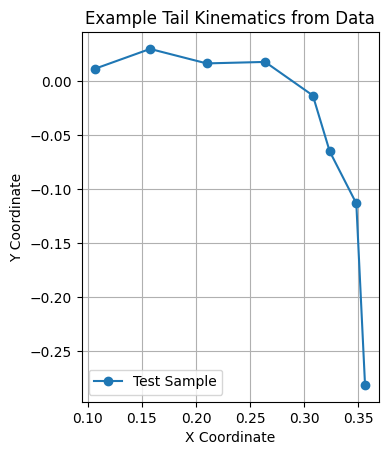

In [71]:
import matplotlib.pyplot as plt
import random

def plot_tail(sample, title="Tail Kinematics", label=None):
    """
    Plot the tail kinematics given a sample of 16 values (8 x-coordinates and 8 y-coordinates).
    Args:
        sample (np.ndarray): 1D array with 16 elements, first 8 are x, next 8 are y.
        title (str): Title of the plot.
    """
    x_coords = sample[:8]
    y_coords = sample[8:16]
    
    plt.plot(x_coords, y_coords, marker='o', label=label)
    plt.legend()
    # plt.xlim(0, 0.6)
    # plt.ylim(-0.4, 0.4)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title(title)
    plt.grid()
    plt.gca().set_aspect('equal')


# Example usage
# Randomly select a sample from data_output and plot
random_index = random.randint(0, data_output.shape[0] - 1)
plot_tail(data_output[random_index], title="Example Tail Kinematics from Data", label="Test Sample")



In [40]:
# import matplotlib.pyplot as plt
# import random

# def plot_tail(sample, title="Tail Kinematics", coordinate_format='xy'):
#     """
#     Plot the tail kinematics given a sample of 16 values (8 x-coordinates and 8 y-coordinates).
#     Args:
#         sample (np.ndarray): 1D array with 16 elements, first 8 are x, next 8 are y.
#         title (str): Title of the plot.
#     """
#     x_coords = sample[:,0]
#     y_coords = sample[:,1]
    
#     #plt.figure(figsize=(6, 6))
#     plt.plot(x_coords, y_coords, marker='o')
#     plt.xlabel('X Coordinate')
#     plt.ylabel('Y Coordinate')
#     plt.title(title)
#     plt.grid()
#     plt.gca().set_aspect('equal')
#     #plt.show()

# # Example usage
# # Randomly select a sample from data_output and plot
# random_index = random.randint(0, data_output.shape[0] - 1)
# plot_tail(data_output[random_index], title="Example Tail Kinematics from Data")

In [41]:
# Dataset preparation

import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F

torch.set_default_dtype(torch.float64)
# Normalize data
# data_input = F.normalize(torch.tensor(data_input, dtype=torch.float64))
# data_output = F.normalize(torch.tensor(data_output, dtype=torch.float64))
# Define dataset split percentages
train_data_percentage = 0.85
valid_data_percentage = 0.1
test_data_percentage = 0.05

train_size = int(len(data_input) * train_data_percentage)
valid_size = int(len(data_input) * valid_data_percentage)
test_size = len(data_input) - train_size - valid_size

valid_index_start = train_size
valid_index_end = train_size + valid_size
test_index_start = valid_index_end
test_index_end = len(data_input) 
#

# Split data into training and validation sets
train_dataset = torch.utils.data.TensorDataset(torch.tensor(data_input[:train_size], dtype=torch.float64), 
                                               torch.tensor(data_output[:train_size], dtype=torch.float64))
valid_dataset = torch.utils.data.TensorDataset(torch.tensor(data_input[valid_index_start:valid_index_end], dtype=torch.float64), 
                                               torch.tensor(data_output[valid_index_start:valid_index_end], dtype=torch.float64))
# valid_dataset_input = torch.tensor(data_input[valid_index_start:valid_index_end], dtype=torch.float64)
# valid_dataset_output = torch.tensor(data_output[valid_index_start:valid_index_end], dtype=torch.float64)
#Test dataset
test_dataset_input = torch.tensor(data_input[test_index_start:test_index_end], dtype=torch.float64)
test_dataset_output = torch.tensor(data_output[test_index_start:test_index_end], dtype=torch.float64)
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=100, shuffle=True)

test_dataset_output.dtype

print(f'Train dataset size: {len(train_dataset)}')
print(f'Validation dataset size: {len(valid_dataset)}')
print(f'Test dataset size: {len(test_dataset_input)}')

Train dataset size: 425000
Validation dataset size: 50000
Test dataset size: 25000


In [42]:
print(f'Test dataset input shape: {test_dataset_input.shape}')
print(f'Test dataset output shape: {test_dataset_output.shape}')

Test dataset input shape: torch.Size([25000, 8, 1])
Test dataset output shape: torch.Size([25000, 16])


In [43]:
# MODEL STRUCTURE

import torch
import torch.nn as nn
import torch.nn.functional as F

class TailKinematicsRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=2, num_layers=8, output_size=16):  
        super(TailKinematicsRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(hidden_size*num_layers, output_size)
        
    def forward(self, x):
        
        out, _ = self.rnn(x)
        out = self.flatten(out)
        out = self.fc(out)  # Get the output of the
        
        return out

# Create the model
model = TailKinematicsRNN()

# Print model summary
print(model)

TailKinematicsRNN(
  (rnn): RNN(1, 2, num_layers=8, batch_first=True)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=16, out_features=16, bias=True)
)


In [44]:
# rand_data = torch.randn((1,8,1), dtype=torch.float32)
# pred = model(rand_data)
# print(pred)

#print(test_dataset_input.shape)
pred = model(test_dataset_input)
#print(pred.shape)

In [45]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
criterion = nn.MSELoss()
# Get one batch from train_loader
input_data, output_data = next(iter(train_loader))
# Move data to GPU if available
input_data, output_data = input_data.to(device), output_data.to(device)
model = model.to(device)
with torch.set_grad_enabled(True):
    # Forward pass
    pred = model(input_data)
    loss = criterion(pred, output_data)

In [46]:
# Training loop
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import torch
from torcheval.metrics.functional import mean_squared_error, r2_score
import math

def train_model(model, criterion, optimizer, best_model_file_name, num_epochs=30):
    best_accuracy = 0.0
    # Select the available device
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    model = model.to(device)
    hist_train_loss = np.zeros((num_epochs,1))
    hist_valid_loss = np.zeros((num_epochs,1))    

    hist_train_r2 = np.zeros((num_epochs,1))
    hist_valid_r2 = np.zeros((num_epochs,1))
    # Training loop
    with tqdm(total=100) as pbar:
        for epoch in range(num_epochs):
            
            model.train()
            running_loss = 0.0
            running_r2 = 0.0
            running_mse = 0.0
            for input_data, output_data in train_loader:
                # Move data to GPU if available
                input_data, output_data = input_data.to(device), output_data.to(device)
                with torch.set_grad_enabled(True):
                    # Forward pass
                    pred = model(input_data)
                    #loss = my_custom_loss(pred, output_data)
                    loss = criterion(pred, output_data)
                    # Backward and optimize
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                # Batch loss and correct predictions
                running_loss += loss.item() * input_data.shape[0] # Multiply for batch size
                running_r2 += r2_score(pred, output_data).item() * input_data.shape[0]
                running_mse += mean_squared_error(pred,output_data).item()* input_data.shape[0]

            # Epoch loss and accuracy
            epoch_loss = running_loss / len(train_dataset)
            r2 = running_r2 / len(train_dataset)
            mse = running_mse / len(train_dataset)
            if (epoch+1) % (num_epochs/10) == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}]:")
                print(f"Train loss: {epoch_loss:1.5E} -- R2: {r2:1.5E} -- MSE: {mse:1.5E} ")
            
            hist_train_loss[epoch] = epoch_loss
            hist_train_r2[epoch] = r2
            
            # Evaluation
            running_loss = 0.0
            running_r2 = 0.0
            running_mse = 0.0
            
            model.eval()
            for input_data, output_data in valid_loader:
                # Move data to GPU if available
                input_data, output_data = input_data.to(device), output_data.to(device)
                with torch.no_grad():
                    pred = model(input_data)
                    #loss = my_custom_loss(pred, output_data)
                    loss = criterion(pred, output_data)
                    running_loss += loss.item()
                # Batch loss and correct predictions
                running_loss += loss.item() * input_data.shape[0] # Multiply for batch size
                running_r2 += r2_score(pred, output_data).item() * input_data.shape[0]
                running_mse += mean_squared_error(pred,output_data)* input_data.shape[0]
            # Epoch loss and accuracy
            epoch_loss = running_loss / len(valid_dataset)
            r2 = running_r2 / len(valid_dataset)
            mse = running_mse / len(valid_dataset)
            
            if (epoch+1) % (num_epochs/10) == 0:
                print(f"Valid loss: {epoch_loss:1.5E} -- R2: {r2:1.5E} -- MSE: {mse:1.5E} ")
                print(60*"=")
                pbar.update(10)
            if r2 > best_accuracy:
                    best_accuracy = r2
                    # Save the model only if its better than the one already saved
                    nn_fncs.save_best_model(model, best_accuracy, 0.9 ,model_name=best_model_file_name)
            
            hist_valid_loss[epoch] = epoch_loss
            hist_valid_r2[epoch] = r2
    plt.plot(hist_train_loss, label='Train Loss')
    plt.plot(hist_valid_loss, label='Valid Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    plt.plot(hist_train_r2, label='Train R2')
    plt.plot(hist_valid_r2, label='Valid R2')
    plt.xlabel('Epoch')
    plt.ylabel('R2')
    plt.legend()
    plt.show()

    print(f"Best validation accuracy: {best_accuracy}")
    return model

In [47]:
# Save the final model
#nn_fncs.save_best_model(model, 0.98, 0.0 ,model_name='final_model')

In [66]:
# TESTING
import torch
from torcheval.metrics.functional import mean_squared_error, r2_score
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# Load the best model
import nn_fncs
model = TailKinematicsRNN()
model_path = nn_fncs.best_model_path('./', model_name='best_model')
model.load_state_dict(torch.load(model_path))
model = model.to(device)

#evaluate the model
model.eval()
print(f"Using device: {device}")
test_dataset_input = test_dataset_input.to(device)
test_dataset_output = test_dataset_output.to(device)
pred = model(test_dataset_input)
print(f'Test dataset predictions shape: {pred.shape}')
distances = point_distances_from_sample(pred[10].cpu().detach().numpy())
print(distances)
mean_squared_error(pred,test_dataset_output)
print(f'My custom loss on test dataset: {my_custom_loss(pred, test_dataset_output):1.5E}')
print(f'MSE loss on test dataset: {mean_squared_error(pred,test_dataset_output):1.5E}')
print(f'R2 on test dataset: {r2_score(pred, test_dataset_output):1.5E}')


Best model loaded: best_model_0.9993029281.pt (Accuracy: 0.9993029281%)
Using device: cuda:0
Test dataset predictions shape: torch.Size([25000, 16])
[0.05389228 0.05352362 0.05435121 0.05457427 0.05298876 0.05372476
 0.16914475]
My custom loss on test dataset: 8.50268E-06
MSE loss on test dataset: 7.19037E-06
R2 on test dataset: 9.99298E-01


torch.Size([25000, 16])
torch.Size([25000, 8, 1])
13787


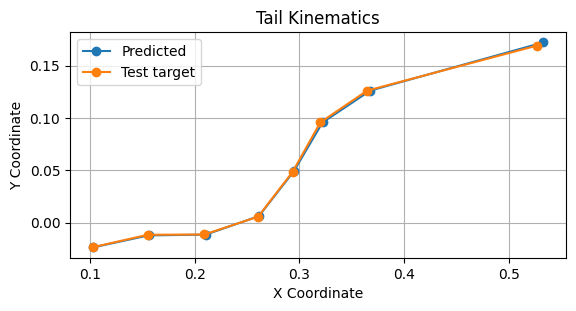

In [76]:
# Visualize random test sample prediction
import matplotlib.pyplot as plt
import random
random_index = random.randint(0, test_dataset_input.shape[0] - 1)
print(pred.shape)
print(test_dataset_input.shape)
print(random_index)
plt.figure()
plot_tail(pred[random_index].cpu().detach().numpy(), label='Predicted')
plot_tail(test_dataset_output[random_index].cpu().detach().numpy(), label="Test target")
plt.grid(True)
plt.show()

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {total_params}")

Number of parameters: 366


In [ ]:
# Export model to ONNX

import torch
dummy_input = torch.randn(1, 8, 1, dtype=torch.float64).to(device)
onnx_model_path = "tail_kinematics_rnn.onnx"
onnx_program = torch.onnx.export(model, dummy_input, dynamo=True, opset_version=14)
onnx_program.save(onnx_model_path)

[torch.onnx] Obtain model graph for `TailKinematicsRNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `TailKinematicsRNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


Conversion to opset < 18 is not supported.
Skipping constant folding for op SplitToSequence with multiple outputs.


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Skipping constant folding for op SplitToSequence with multiple outputs.


In [ ]:
# Save traced model
import torch
dummy_input = torch.randn(1, 8, 1, dtype=torch.float64).to(device)
torch.jit.trace(model, dummy_input).save("tail_kinematics_rnn_traced.pt")

In [ ]:
# Calculate prediction time
import time
model.eval()
data = torch.randn((1,8,1), dtype=torch.float64).to(device)
start_time = time.time()
pred = model(data)
end_time = time.time()
print(f"Prediction time for one sample: {end_time - start_time:1.5E} seconds")




Prediction time for one sample: 2.54512E-03 seconds


In [ ]:
# Calculate prediction time
import time
import torch

data = torch.randn((1,8,1), dtype=torch.float64).to(device)
start = time.perf_counter()
pred = model(data)
end = time.perf_counter()
print(f"Prediction time for one sample: {end - start:1.5E} seconds")

Prediction time for one sample: 3.42750E-03 seconds
